Inpirations / Learning tools:
[ Sentiment Analysis with BERT Neural Network and Python ](https://www.youtube.com/watch?v=szczpgOEdXs&t=1083s)

# Import data, create model

In [111]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn

In [112]:
# Choose model

model_id = "nlptown/bert-base-multilingual-uncased-sentiment"
#model_id = "tabularisai/multilingual-sentiment-analysis"

In [113]:
# Create model
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSequenceClassification.from_pretrained(model_id)

In [114]:
df = pd.read_csv('data/reddit_posts.csv')
df.columns

Index(['Title', 'Political Lean', 'Score', 'Id', 'Subreddit', 'URL',
       'Num of Comments', 'Text', 'Date Created'],
      dtype='object')

# Define function for sentiment analysis:

In [115]:
def sentiment_analysis(model, post_str):
    tokens = tokenizer.encode(post_str, return_tensors="pt")
    result = model(tokens)
    if int(torch.argmax(result.logits)) < 0:
        print(post_str)
    return int(torch.argmax(result.logits)) + 1

In [116]:
#create new column in df:
df["Sentiment"] = 0

for i in range(0, len(df)):
    df.at[i, "Sentiment"] = sentiment_analysis(model, df.iloc[i]["Title"])

df.to_csv("data/reddit_posts_sentiment.csv", sep=";", index=False)

# Visualisations

[0.53274531 0.05622933 0.08511577 0.11510474 0.21080485]
Sentiment
1    2416
2     255
3     386
4     522
5     956
dtype: int64


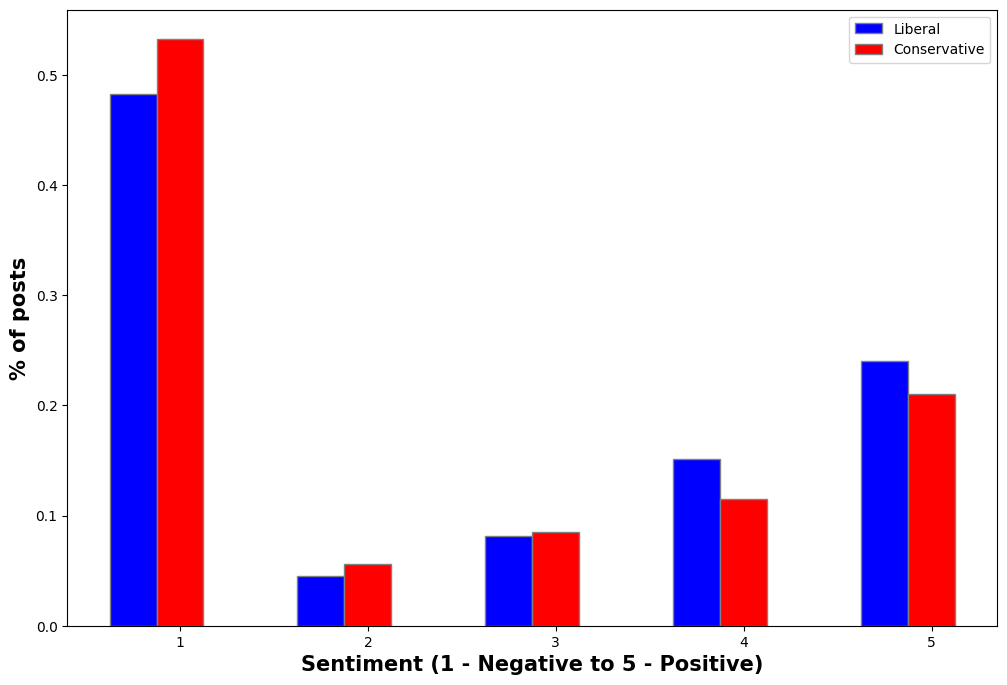

In [ ]:
# Dichotomy lib / cons


num_lib_posts = df.groupby("Political Lean").size()["Liberal"]
num_cons_posts = df.groupby("Political Lean").size()["Conservative"]
sentiments_lib_cat = df[df["Political Lean"] == "Liberal"].groupby(by="Sentiment").size().to_list() / num_lib_posts
sentiments_cons_cat = df[df["Political Lean"] == "Conservative"].groupby(by="Sentiment").size().to_list() / num_cons_posts

barWidth = 0.25
fig = plt.subplots(figsize =(12, 8))

br1 = np.arange(len(sentiments_lib_cat)) 
br2 = [x + barWidth for x in br1] 

plt.bar(br1, sentiments_lib_cat, color ='b', width = barWidth, 
        edgecolor ='grey', label ='Liberal') 
plt.bar(br2, sentiments_cons_cat, color ='r', width = barWidth, 
        edgecolor ='grey', label ='Conservative')

plt.xlabel('Sentiment (1 - Negative to 5 - Positive)', fontweight ='bold', fontsize = 15) 
plt.ylabel('% of posts', fontweight ='bold', fontsize = 15) 
plt.xticks([r + barWidth for r in range(len(sentiments_lib_cat))], 
        ['1', '2', '3', '4', '5'])

plt.legend()
plt.show()  

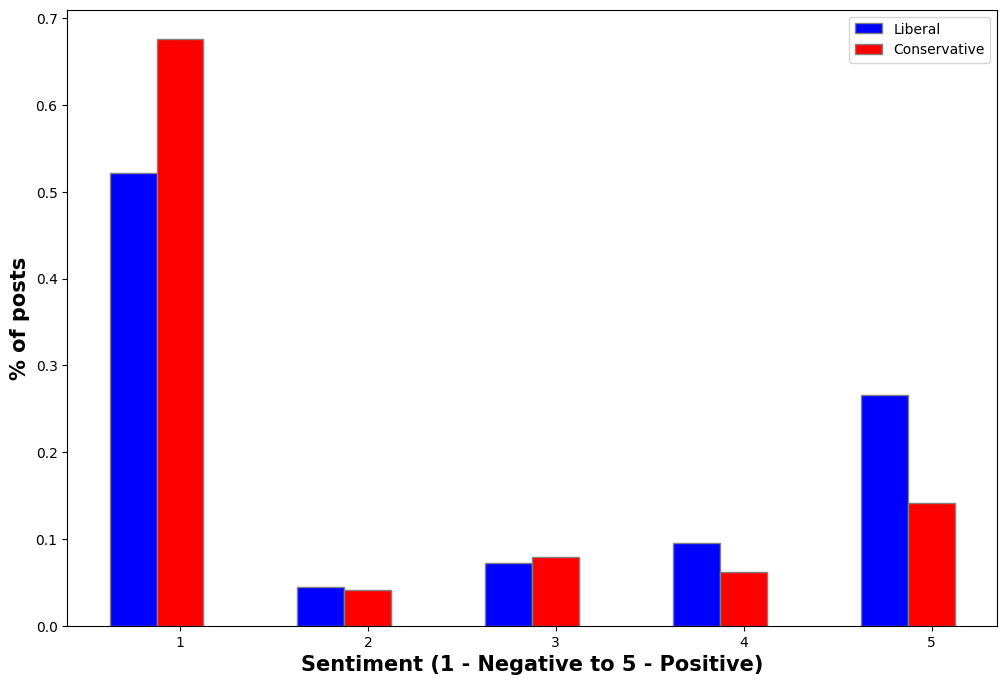

In [ ]:
sentiment_lib_weighted = [0,0,0,0,0]
sentiment_cons_weighted = [0,0,0,0,0]
for i in range(len(df)):
    post = df.iloc[i]
    if post["Political Lean"] == "Liberal":
        sentiment_lib_weighted[post["Sentiment"]-1] += post["Score"]
    if post["Political Lean"] == "Conservative":
        sentiment_cons_weighted[post["Sentiment"]-1] += post["Score"]

sentiment_lib_weighted = sentiment_lib_weighted / sum(sentiment_lib_weighted)
sentiment_cons_weighted = sentiment_cons_weighted / sum(sentiment_cons_weighted)

barWidth = 0.25
fig = plt.subplots(figsize =(12, 8))

br1 = np.arange(len(sentiments_lib_cat)) 
br2 = [x + barWidth for x in br1] 

plt.bar(br1, sentiment_lib_weighted, color ='b', width = barWidth, 
        edgecolor ='grey', label ='Liberal') 
plt.bar(br2, sentiment_cons_weighted, color ='r', width = barWidth, 
        edgecolor ='grey', label ='Conservative')

plt.xlabel('Sentiment (1 - Negative to 5 - Positive) (weighted by number of upvotes)', fontweight ='bold', fontsize = 15) 
plt.ylabel('% of posts', fontweight ='bold', fontsize = 15) 
plt.xticks([r + barWidth for r in range(len(sentiment_lib_weighted))], 
        ['1', '2', '3', '4', '5'])

plt.legend()
plt.show()  